In [38]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from pathlib import Path
df_raw = pd.read_csv(Path("../../dataset/data/final_dataset_new_corrected.csv"))
sns.set_theme(style='whitegrid')
PALETTE = {'Agentic': '#A7C7E7', 'Developer': '#BDE5B8'}


df_raw['doc_lines'] = pd.to_numeric(df_raw['doc_lines'], errors='coerce')

df = df_raw[df_raw['doc_lines'] > 0].copy()
df = df[df['doc_text'].notna() & (df['doc_text'].str.strip() != '')].copy()

# Map groups to labels matching RQ5 convention
df['author_type'] = df['group'].map({'agent': 'Agentic', 'human': 'Developer'})

print(f"Documented-function dataset: {df.shape}")
print(df['author_type'].value_counts().to_dict())

Documented-function dataset: (6174, 31)
{'Agentic': 3986, 'Developer': 2188}


In [ ]:
# CODE-TOKEN STRIPPING FUNCTION

# Common type/keyword tokens to strip
TYPE_KEYWORDS = {
    'int', 'str', 'bool', 'float', 'bytes', 'list', 'dict', 'tuple', 'set',
    'void', 'none', 'null', 'undefined', 'true', 'false', 'any', 'object',
    'array', 'string', 'number', 'boolean', 'char', 'long', 'short', 'double',
    'List', 'Dict', 'Tuple', 'Set', 'Optional', 'Union', 'Type', 'Callable',
    'Generator', 'Iterator', 'Sequence', 'Mapping', 'Iterable', 'TypeVar',
    'async', 'await', 'def', 'class', 'return', 'yield', 'import', 'from',
    'raise', 'except', 'try', 'with', 'lambda', 'self', 'cls',
}
TYPE_KEYWORDS_LOWER = {t.lower() for t in TYPE_KEYWORDS}

# Regex patterns for code-like tokens
_RE_BACKTICK = re.compile(r'`[^`]*`')           # backtick-quoted spans
_RE_CAMEL    = re.compile(r'\b[a-z]+[A-Z][a-zA-Z0-9]*\b')  # camelCase
_RE_SNAKE    = re.compile(r'\b\w*_\w+\b')       # contains underscore
_RE_ALNUM    = re.compile(r'\b(?=[a-zA-Z]*\d)[a-zA-Z0-9]+\b')  # letters+digits mixed
_RE_PUNCT_HEAVY = re.compile(r'[\[\](){}|<>:,;=]{2,}')  # dense punctuation

def strip_code_tokens(text: str) -> str:

    if not isinstance(text, str) or not text.strip():
        return ''

    # 1. Strip backtick spans first
    text = _RE_BACKTICK.sub(' ', text)

    # 2. Strip dense punctuation sequences
    text = _RE_PUNCT_HEAVY.sub(' ', text)

    # 3. Strip camelCase tokens
    text = _RE_CAMEL.sub(' ', text)

    # 4. Strip snake_case tokens
    text = _RE_SNAKE.sub(' ', text)

    # 5. Strip letter+digit mixed tokens
    text = _RE_ALNUM.sub(' ', text)

    # 6. Strip type keywords (word-boundary match, case-insensitive)
    words = text.split()
    words = [w for w in words if w.lower().strip('.,;:()[]{}') not in TYPE_KEYWORDS_LOWER]
    text = ' '.join(words)

    # 7. Collapse whitespace
    return re.sub(r'\s+', ' ', text).strip()

#test
sample = 'Returns the List[str] of items. Uses param1 and `my_var` to compute getResult(). Raises ValueError if invalid.'
print('Original:')
print(' ', sample)
print('Cleaned:')
print(' ', strip_code_tokens(sample))

Original:
  Returns the List[str] of items. Uses param1 and `my_var` to compute getResult(). Raises ValueError if invalid.
Cleaned:
  Returns the List[str] of items. Uses and to compute . Raises ValueError if invalid.


In [ ]:
# BUILD RAW AND CLEANED TEXT

print('Extracting and cleaning text...')
df['prose_raw']     = df['doc_text']
df['prose_cleaned'] = df['prose_raw'].apply(strip_code_tokens)

# How much text survives cleaning?
raw_len  = df['prose_raw'].str.split().str.len().median()
cln_len  = df['prose_cleaned'].str.split().str.len().median()
print(f"Median word count: raw={raw_len:.0f}, cleaned={cln_len:.0f} ({100*cln_len/raw_len:.0f}% retained)")

Extracting and cleaning text...
Median word count: raw=10, cleaned=10 (100% retained)


In [ ]:
# READABILITY SCORING

try:
    import textstat
    HAS_TEXTSTAT = True
except ImportError:
    HAS_TEXTSTAT = False
    print('WARNING: textstat not installed. Install with: pip install textstat')

READ_METRICS = ['flesch_reading_ease', 'smog_index', 'flesch_kincaid_grade']

def score_readability(text: str) -> dict:
    if not HAS_TEXTSTAT or not isinstance(text, str) or not text.strip():
        return {m: np.nan for m in READ_METRICS}
    # textstat needs at least a few sentences for SMOG; guard gracefully
    result = {}
    for fn_name in READ_METRICS:
        try:
            result[fn_name] = getattr(textstat, fn_name)(text)
        except Exception:
            result[fn_name] = np.nan
    return result

print('Scoring readability on raw text...')
raw_scores = df['prose_raw'].apply(score_readability)
for m in READ_METRICS:
    df[f'raw_{m}'] = [s[m] for s in raw_scores]

print('Scoring readability on cleaned text...')
cln_scores = df['prose_cleaned'].apply(score_readability)
for m in READ_METRICS:
    df[f'cln_{m}'] = [s[m] for s in cln_scores]

print('Done.')

Scoring readability on raw text...
Scoring readability on cleaned text...
Done.


In [ ]:
# STATISTICAL COMPARISON


def mw_effect(a, b):
    a = a.dropna().values
    b = b.dropna().values
    if len(a) < 5 or len(b) < 5:
        return np.nan, np.nan, np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * stat) / (len(a) * len(b))
    return stat, p, r

ag = df[df['author_type'] == 'Agentic']
hu = df[df['author_type'] == 'Developer']

rows = []
print('=== Readability Robustness Results ===')
print(f"{'Metric':<30} {'Cond':<8} {'Agent med':>10} {'Dev med':>10} {'r_rb':>8} {'p':>10} {'sig':>6} {'effect'}")
print('-' * 90)

for metric, display_name in [
    ('flesch_reading_ease', 'Flesch Reading Ease'),
    ('smog_index',          'SMOG Index'),
    ('flesch_kincaid_grade','Flesch-Kincaid Grade'),
]:
    for prefix, cond_label in [('raw', 'raw'), ('cln', 'cleaned')]:
        col = f'{prefix}_{metric}'
        _, p, r = mw_effect(ag[col], hu[col])

        ag_med = ag[col].median()
        hu_med = hu[col].median()
        sig    = '*' if (p is not np.nan and not np.isnan(p) and p < 0.05) else 'ns'
        eff    = ('negligible' if abs(r) < 0.1 else ('small' if abs(r) < 0.3 else
                  ('medium' if abs(r) < 0.5 else 'large'))) if (r is not np.nan and not np.isnan(r)) else 'n/a'

        print(f"{display_name:<30} {cond_label:<8} {ag_med:>10.2f} {hu_med:>10.2f} {r:>8.4f} {p:>10.3e} {sig:>6} {eff}")

        rows.append({
            'metric':          display_name,
            'condition':       cond_label,
            'agent_median':    ag_med,
            'developer_median':hu_med,
            'rank_biserial_r': r,
            'p_value':         p,
            'significant':     sig == '*',
            'effect_size':     eff,
        })

results_df = pd.DataFrame(rows)

=== Readability Robustness Results ===
Metric                         Cond      Agent med    Dev med     r_rb          p    sig effect
------------------------------------------------------------------------------------------
Flesch Reading Ease            raw           38.38      52.87   0.1371  4.406e-19      * small
Flesch Reading Ease            cleaned       37.55      54.73   0.1880  2.091e-34      * small
SMOG Index                     raw           10.13       8.84  -0.0744  9.149e-07      * negligible
SMOG Index                     cleaned       10.13       8.84  -0.0970  1.466e-10      * negligible
Flesch-Kincaid Grade           raw           10.21       8.55  -0.0962  3.750e-10      * negligible
Flesch-Kincaid Grade           cleaned       10.05       8.35  -0.1511  8.417e-23      * small


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# SIDE-BY-SIDE SUMMARY TABLE
# ─────────────────────────────────────────────────────────────────────────────
pivot = results_df.pivot(index='metric', columns='condition')

summary_rows = []
for metric in results_df['metric'].unique():
    raw_row = results_df[(results_df['metric'] == metric) & (results_df['condition'] == 'raw')].iloc[0]
    cln_row = results_df[(results_df['metric'] == metric) & (results_df['condition'] == 'cleaned')].iloc[0]

    r_change = (cln_row['rank_biserial_r'] - raw_row['rank_biserial_r'])
    direction = ('⬆ increased' if r_change > 0.01 else
                 ('⬇ decreased' if r_change < -0.01 else '≈ stable'))

    summary_rows.append({
        'metric':                 metric,
        'orig_agent_median':      raw_row['agent_median'],
        'orig_dev_median':        raw_row['developer_median'],
        'orig_effect_size':       raw_row['effect_size'],
        'orig_significant':       raw_row['significant'],
        'cleaned_agent_median':   cln_row['agent_median'],
        'cleaned_dev_median':     cln_row['developer_median'],
        'cleaned_effect_size':    cln_row['effect_size'],
        'cleaned_significant':    cln_row['significant'],
        'r_rb_change':            r_change,
        'direction':              direction,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.to_string(index=False, float_format='{:.3f}'.format))

summary_df.to_csv(os.path.join(OUT_DIR, 'readability_robustness.csv'), index=False)
print('\nSaved readability_robustness.csv')

'              metric  orig_agent_median  orig_dev_median orig_effect_size  orig_significant  cleaned_agent_median  cleaned_dev_median cleaned_effect_size  cleaned_significant  r_rb_change   direction\n Flesch Reading Ease             38.378           52.865            small              True                37.545              54.725               small                 True        0.051 ⬆ increased\n          SMOG Index             10.126            8.842       negligible              True                10.126               8.842          negligible                 True       -0.023 ⬇ decreased\nFlesch-Kincaid Grade             10.209            8.547       negligible              True                10.053               8.353               small                 True       -0.055 ⬇ decreased'


Saved readability_robustness.csv


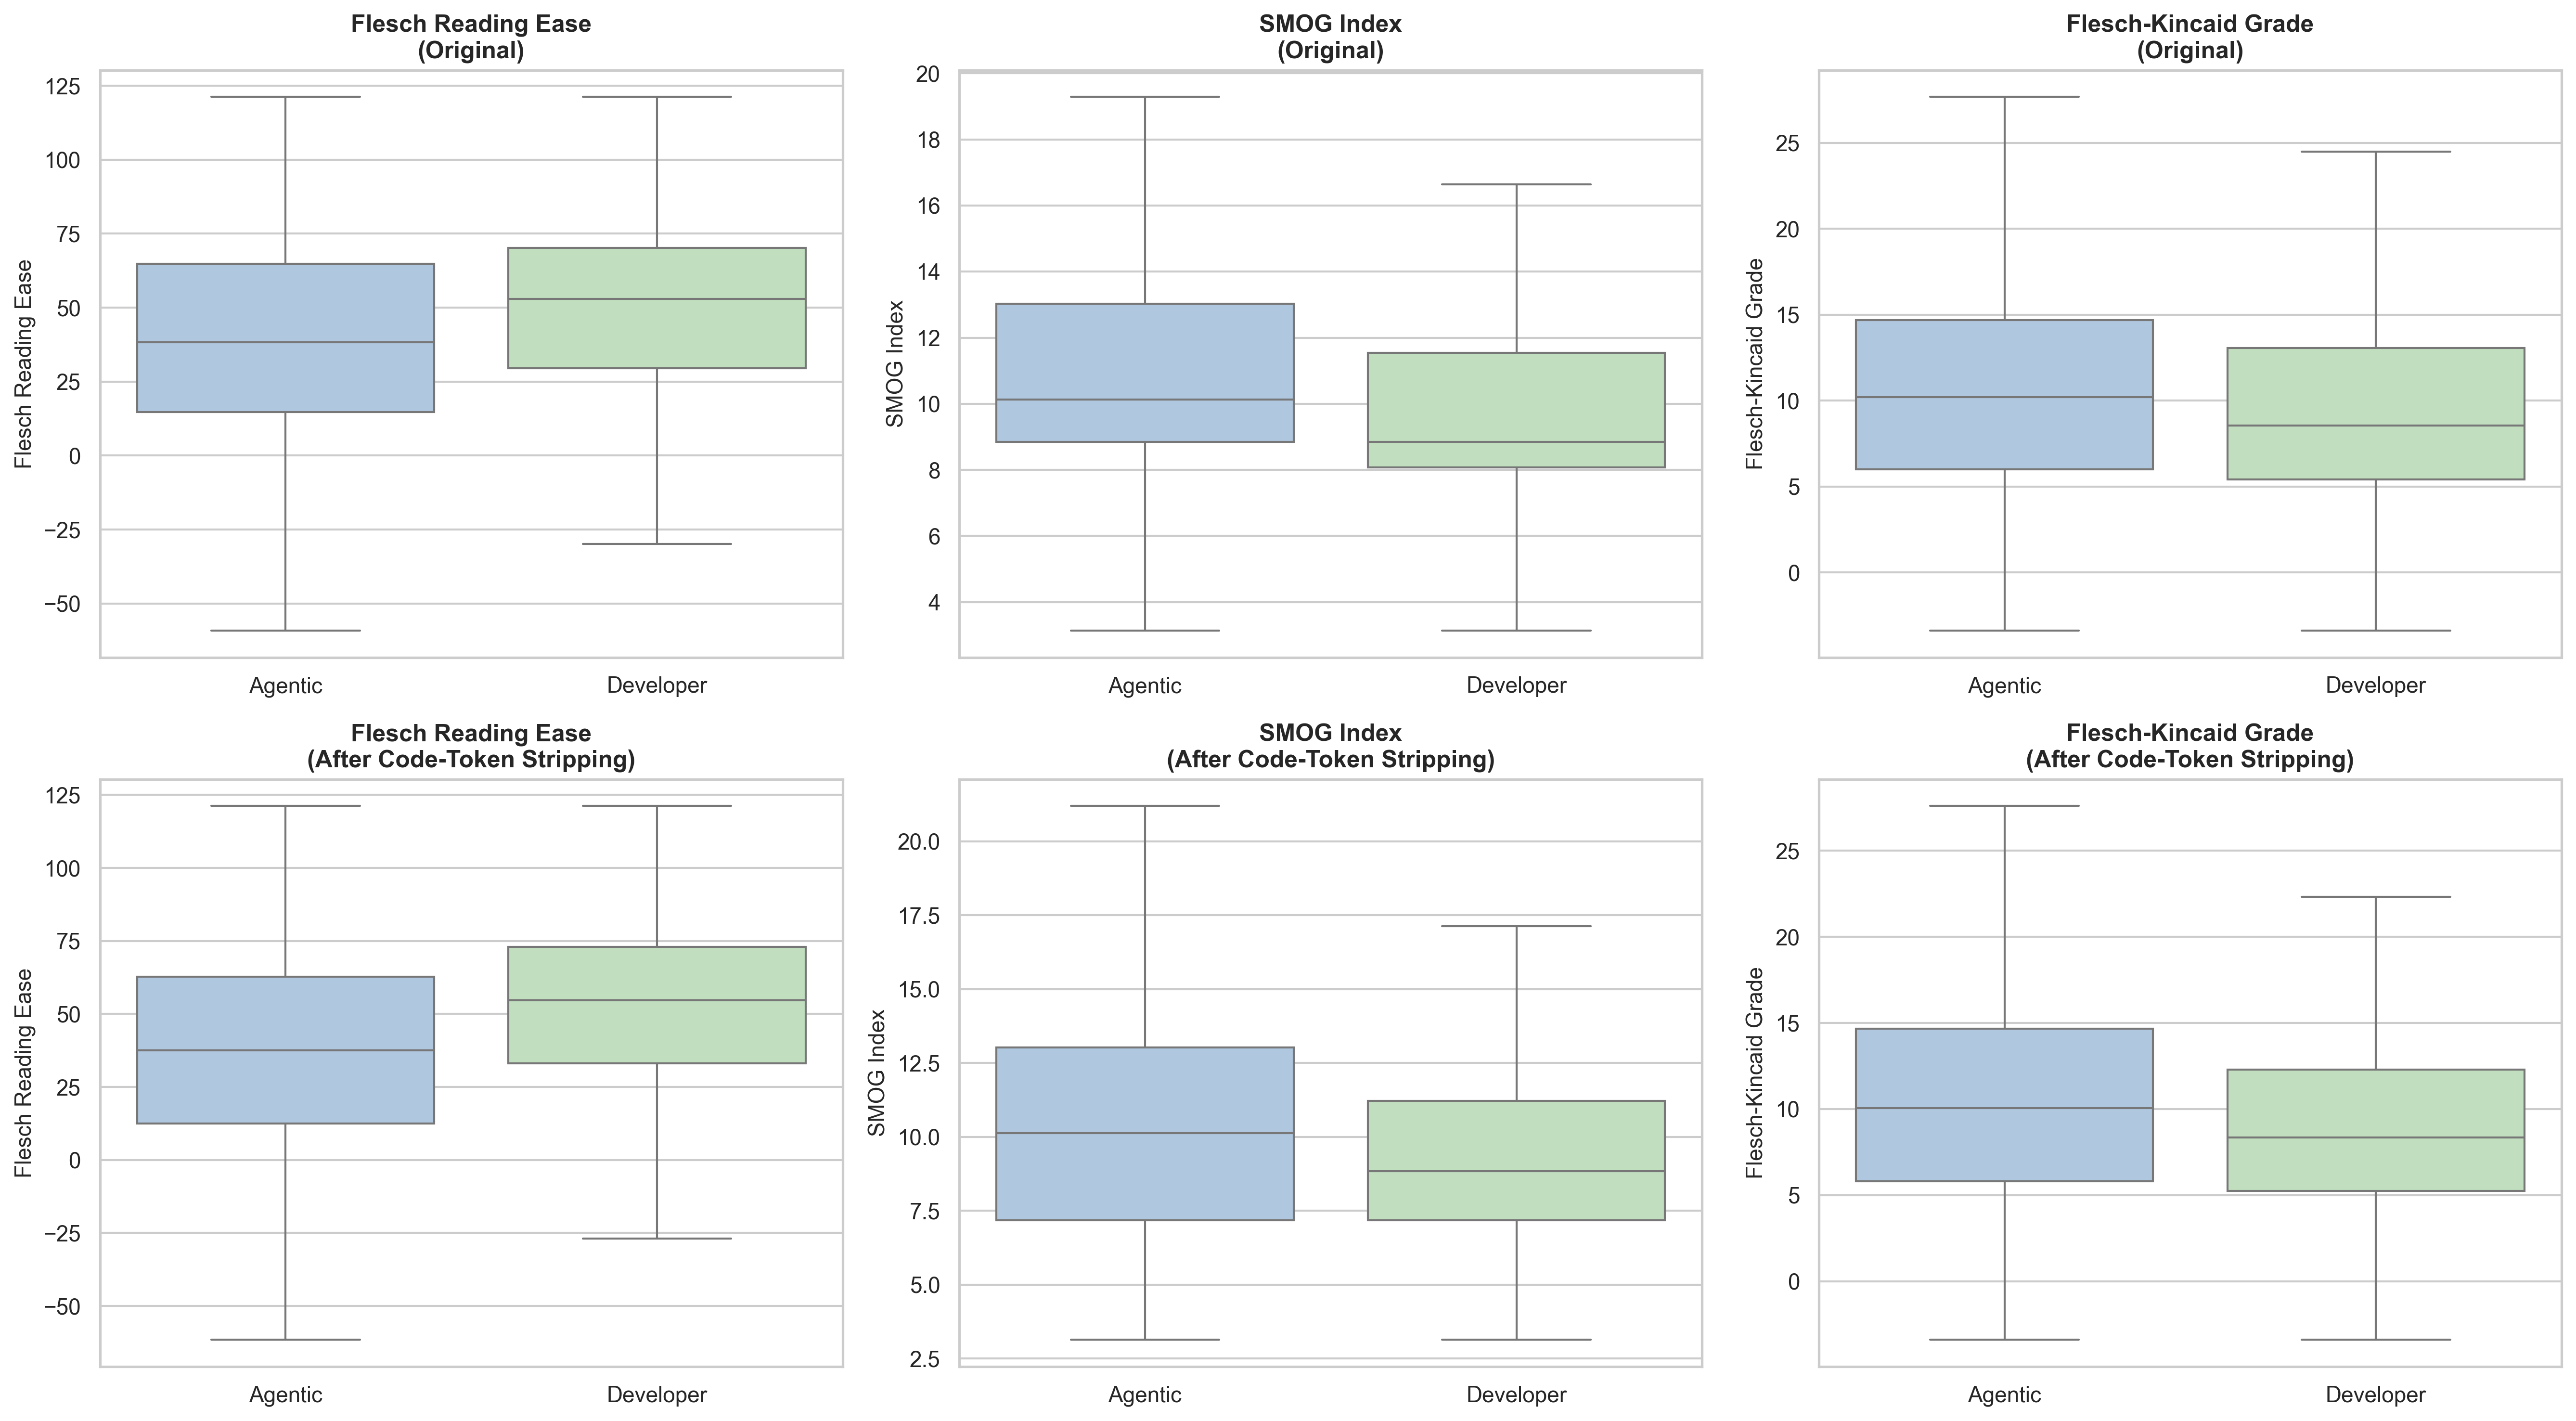

Saved readability_robustness_plot.png


In [ ]:
# VISUALISATION 

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)

metric_names = ['flesch_reading_ease', 'smog_index', 'flesch_kincaid_grade']
display_names = ['Flesch Reading Ease', 'SMOG Index', 'Flesch-Kincaid Grade']

for col_i, (metric, dname) in enumerate(zip(metric_names, display_names)):
    for row_i, (prefix, cond_label) in enumerate([('raw', 'Original'), ('cln', 'After Code-Token Stripping')]):
        ax = axes[row_i][col_i]
        col = f'{prefix}_{metric}'

        plot_df = df[['author_type', col]].dropna()
        sns.boxplot(
            data=plot_df, x='author_type', y=col,
            palette=PALETTE, showfliers=False, ax=ax,
            order=['Agentic', 'Developer']
        )
        ax.set_title(f'{dname}\n({cond_label})', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(dname, fontsize=11)
        ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'readability_robustness_plot.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved readability_robustness_plot.png')

In [45]:
print('=== INTERPRETATION ===')
for _, row in summary_df.iterrows():
    persists = row['cleaned_significant']
    print(f"\n{row['metric']}:")
    print(f"  Original:  agent={row['orig_agent_median']:.2f}  dev={row['orig_dev_median']:.2f}  "
          f"sig={row['orig_significant']}  effect={row['orig_effect_size']}")
    print(f"  Cleaned:   agent={row['cleaned_agent_median']:.2f}  dev={row['cleaned_dev_median']:.2f}  "
          f"sig={row['cleaned_significant']}  effect={row['cleaned_effect_size']}")
    print(f"  Effect size change: {row['direction']} (Δr = {row['r_rb_change']:+.4f})")
    if persists:
        print(f"  Difference PERSISTS after code-token removal")
    else:
        print(f"  Difference DOES NOT PERSIST")

=== INTERPRETATION ===

Flesch Reading Ease:
  Original:  agent=38.38  dev=52.87  sig=True  effect=small
  Cleaned:   agent=37.55  dev=54.73  sig=True  effect=small
  Effect size change: ⬆ increased (Δr = +0.0509)
  Difference PERSISTS after code-token removal

SMOG Index:
  Original:  agent=10.13  dev=8.84  sig=True  effect=negligible
  Cleaned:   agent=10.13  dev=8.84  sig=True  effect=negligible
  Effect size change: ⬇ decreased (Δr = -0.0226)
  Difference PERSISTS after code-token removal

Flesch-Kincaid Grade:
  Original:  agent=10.21  dev=8.55  sig=True  effect=negligible
  Cleaned:   agent=10.05  dev=8.35  sig=True  effect=small
  Effect size change: ⬇ decreased (Δr = -0.0549)
  Difference PERSISTS after code-token removal
